La pseudoinversa de Moore Penrose es una aplicación directa de *singular value decomposition (*SVD), que nos permite resolver en determinados momentos sistemas de ecuaciones lineales con múltiples soluciones.

La matriz pseudoinversa es utilizada cuando en un sistema de ecuaciones lineales, representado por Ax = B, x no tiene inversa. Esta operación es única y existe si se verifican 4 condiciones.

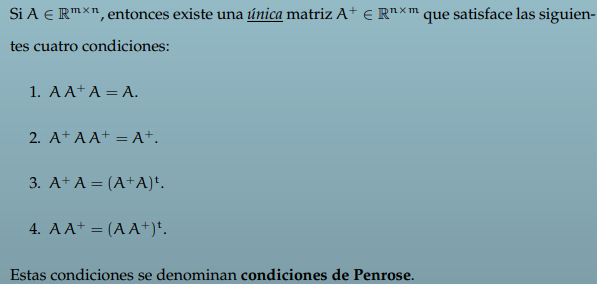

Para calcularla se siguen los siguientes pasos:

Calcular las matrices U, D, y V (matrices SVD) de A.
Construir D_pse: una matriz de ceros que tiene igual dimension de A, y que luego se transpone.
Reemplazar la submatriz D_pse[: D.shape[0], : D.shape[0]] por np.linalg.inv(np.diag(D))
Reconstruir pseudoinversa: A_pse = V.T.dot(D_pse).dot(U.T)
Cómo calcular la pseudoinversa de Moore Penrose en Python
Para calcularla automáticamente por Python: np.linalg.pinv(A)Lo que obtenemos con A_pse es una matriz muy cercana a la inversa. Cercano en el sentido de que minimiza la norma dos de estas distancias. O sea, de estos errores que estamos cometiendo.

In [ ]:
import numpy as np

np.set_printoptions(suppress=True) #  modifies the global print options for NumPy arrays.

In [2]:
A = np.array([[2, 3], [5, 7], [11, 13]])
print(A)

[[ 2  3]
 [ 5  7]
 [11 13]]


In [3]:
U, D, V = np.linalg.svd(A)
print("U")
print(U)
print("D")
print(D)
print("V")
print(V)

U
[[-0.18499741 -0.47276624 -0.86154979]
 [-0.44249308 -0.74271297  0.50257071]
 [-0.87748267  0.4742041  -0.07179582]]
D
[19.40321383  0.71783924]
V
[[-0.63055377 -0.77614557]
 [ 0.77614557 -0.63055377]]


In [4]:
D_pse = np.zeros((A.shape[0], A.shape[1])).T
print(D_pse)

[[0. 0. 0.]
 [0. 0. 0.]]


In [5]:
print("Valores a reemplazar en D_pse")
print(D_pse[:D.shape[0], :D.shape[0]])

Valores a reemplazar en D_pse
[[0. 0.]
 [0. 0.]]


In [6]:
print("Valores que pondremos en D_pse")
print(np.linalg.inv(np.diag(D)))

Valores que pondremos en D_pse
[[0.05153785 0.        ]
 [0.         1.39306957]]


In [7]:
print("D_pse")
D_pse[:D.shape[0], :D.shape[0]] = np.linalg.inv(np.diag(D))
print(D_pse)

D_pse
[[0.05153785 0.         0.        ]
 [0.         1.39306957 0.        ]]


In [8]:
A_pse = V.T.dot(D_pse).dot(U.T)
print(A_pse)

[[-0.50515464 -0.78865979  0.54123711]
 [ 0.42268041  0.67010309 -0.3814433 ]]


In [9]:
A_pse_calc = np.linalg.pinv(A)
print(A_pse_calc)

[[-0.50515464 -0.78865979  0.54123711]
 [ 0.42268041  0.67010309 -0.3814433 ]]


In [10]:
print(A_pse.dot(A))

[[ 1. -0.]
 [ 0.  1.]]


In [11]:
np.set_printoptions(suppress = False)

In [12]:
print(A_pse.dot(A))

[[ 1.00000000e+00 -1.77635684e-15]
 [ 4.44089210e-16  1.00000000e+00]]


In [15]:
print(A.dot(A_pse))

[[ 0.25773196  0.43298969 -0.06185567]
 [ 0.43298969  0.74742268  0.03608247]
 [-0.06185567  0.03608247  0.99484536]]


In [16]:
A_pse_2 = np.linalg.inv(A.T.dot(A)).dot(A.T)
print(A_pse_2)

[[-0.50515464 -0.78865979  0.54123711]
 [ 0.42268041  0.67010309 -0.3814433 ]]


In [17]:
print(A_pse)

[[-0.50515464 -0.78865979  0.54123711]
 [ 0.42268041  0.67010309 -0.3814433 ]]
